# Anomaly Detection Evaluation

## 1. Setup & Configuration

In [1]:
# Auto-reload modules
%load_ext autoreload
%autoreload 2

In [2]:
# Imports - Clean refactored API
import matplotlib.pyplot as plt
from pathlib import Path

from evaluation.runner import run_evaluation, run_single_object, run_few_shot, run_zero_shot, ExperimentResults, MethodResults
from evaluation.visualization import  plot_single_result, plot_method_comparison, plot_object_heatmap, plot_shot_count_analysis
from evaluation.export import  export_all


from utils.DINOv3Wrapper import DINOv3Wrapper
from utils.mvtechDataset import ensure_mvtech_dataset_is_downloaded, get_categories, load_mvtec_data

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

In [3]:
# Configuration
CONFIG = {
    'model_name': 'facebook/dinov3-vits16-pretrain-lvd1689m',
    'smaller_edge_size': 640,
    'k_values': [1, 2], #[1, 2, 4, 8]
    'objects': None,  # None = all, or ['bottle', 'hazelnut']
    'use_rotation': True,
    'use_masking': True,
    'masking_method': "pca",
    'segmentation_method': 'gmm',
    'k_neighbors': 3,
    'output_dir': Path('evaluation_results_clean'),
    'objects': ["hazelnut"]
}

CONFIG['output_dir'].mkdir(exist_ok=True)
print('Configuration:', CONFIG)

Configuration: {'model_name': 'facebook/dinov3-vits16-pretrain-lvd1689m', 'smaller_edge_size': 640, 'k_values': [1, 2], 'objects': ['hazelnut'], 'use_rotation': True, 'use_masking': True, 'masking_method': 'pca', 'segmentation_method': 'gmm', 'k_neighbors': 3, 'output_dir': WindowsPath('evaluation_results_clean')}


In [4]:
# Load dataset and model
dataset_path = ensure_mvtech_dataset_is_downloaded('.')
categories = get_categories(dataset_path)
objects_to_eval = CONFIG['objects'] if CONFIG['objects'] else categories

print(f'Found {len(categories)} categories')
print(f'Will evaluate: {objects_to_eval}')

model = DINOv3Wrapper(
    model_name=CONFIG['model_name'],
    smaller_edge_size=CONFIG['smaller_edge_size']
)

Dataset already exists at .\mvtec_anomaly_detection
Found 15 categories
Will evaluate: ['hazelnut']
Dino is using CUDA
Loading facebook/dinov3-vits16-pretrain-lvd1689m on cuda...
Model loaded! Hidden dim: 384, Register tokens: 4, Patch size: 16
Smaller edge size: 640


## 2. Quick Single-Object Test

In [5]:
# Quick test
test_result = run_single_object(
    method_fn=run_few_shot,
    model=model,
    dataset_path=Path(dataset_path),
    object_name='hazelnut',
    k=2,
    method_kwargs={
        'use_rotation': CONFIG['use_rotation'], 
        'use_masking': CONFIG['use_masking'], 
        'masking_method': CONFIG['masking_method'], 
        'segmentation_method': CONFIG['segmentation_method'], 
        'k_neighbors': CONFIG['k_neighbors']
    }
)

print('Metrics:')
for m, v in test_result.metrics.items():
    print(f'  {m}: {v:.4f}')

Loaded 2 reference images for hazelnut
Loaded 110 test images (70 anomalous, 40 normal)
Running 2_shot evaluation on hazelnut...
Building memory bank from 2 images...
Rotation augmentation: True


Processing reference images:   0%|          | 0/2 [00:00<?, ?it/s]

Memory bank built! Index size: 25600, hnswlib HNSW index


Detecting anomalies (hazelnut):   0%|          | 0/110 [00:00<?, ?it/s]

  AUROC: 0.9821, AU-PRO: 0.9111, IoU: 0.4547
Metrics:
  auroc: 0.9821
  aupro: 0.9111
  pixel_auroc: 0.9930
  pixel_f1: 0.8139
  mean_iou: 0.4547


Loaded 8 reference images for hazelnut
Loaded 110 test images (70 anomalous, 40 normal)
gmm


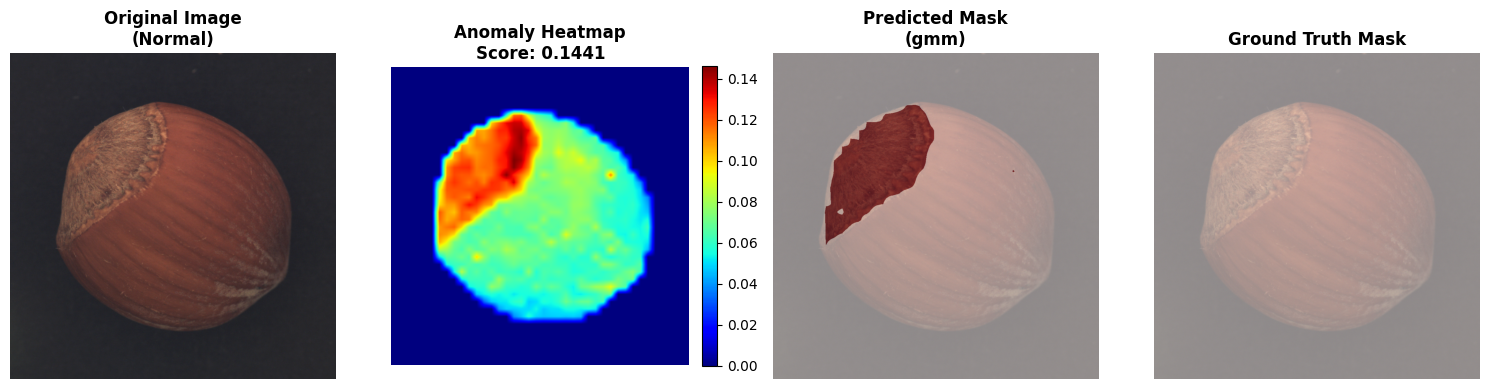

gmm


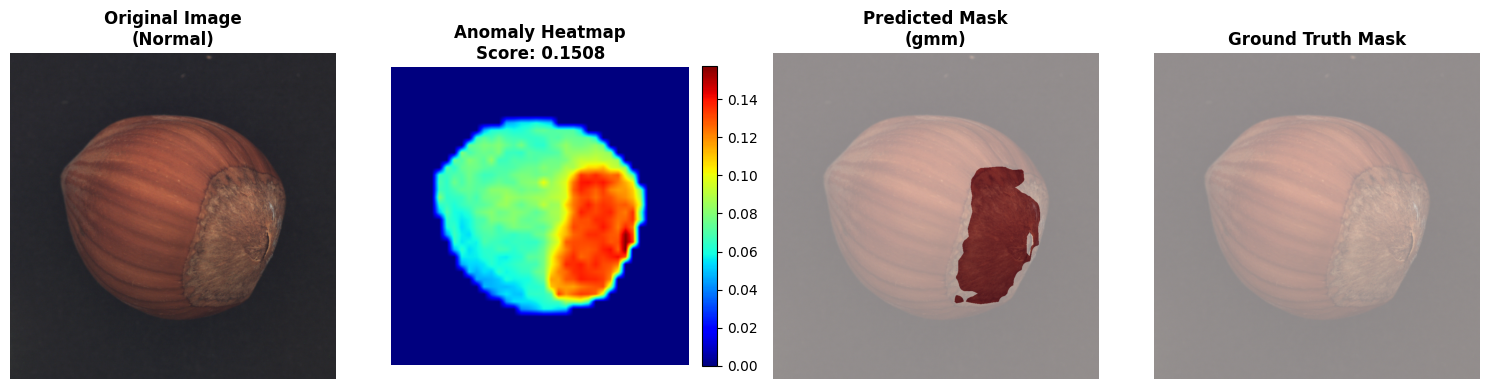

gmm


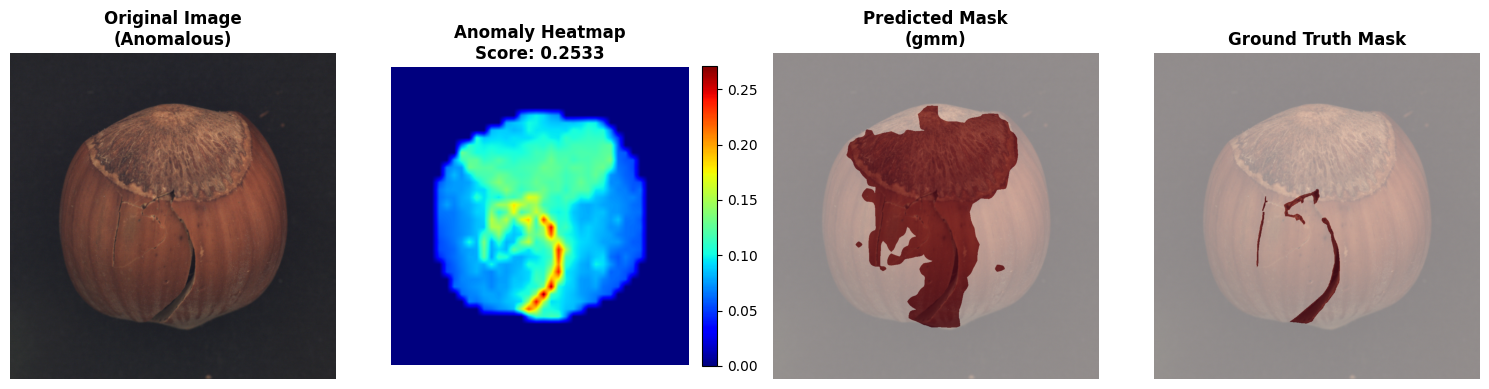

gmm


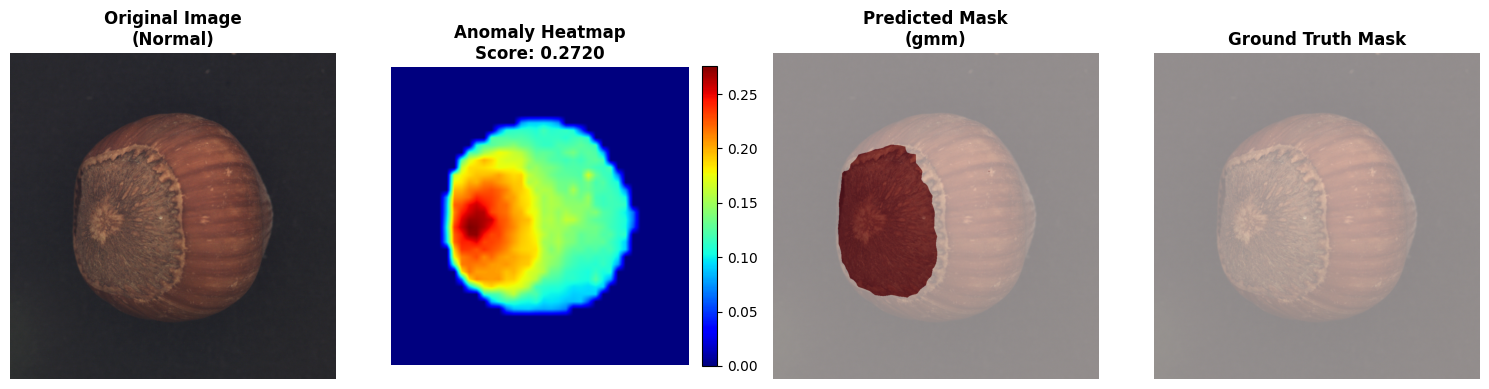

gmm


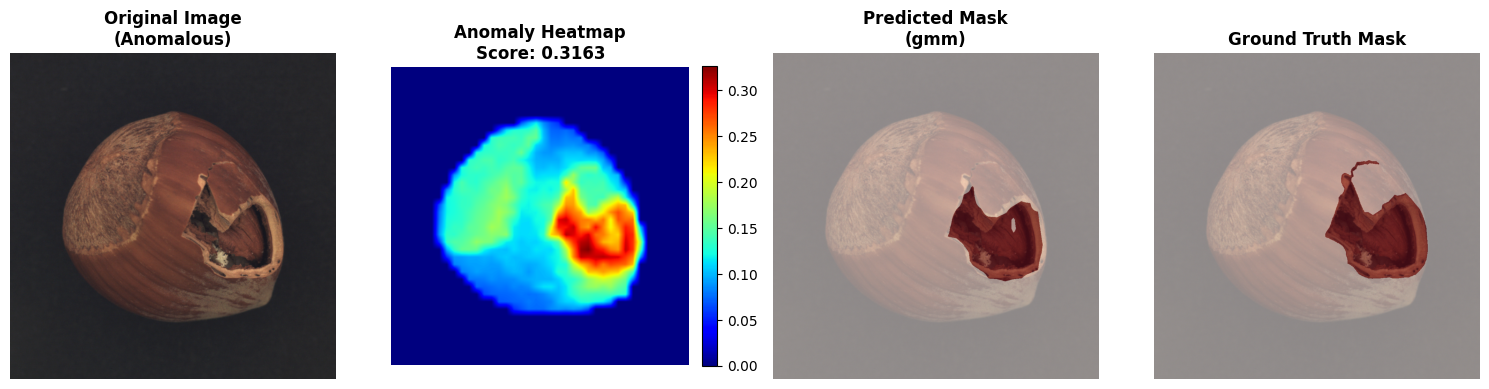

gmm


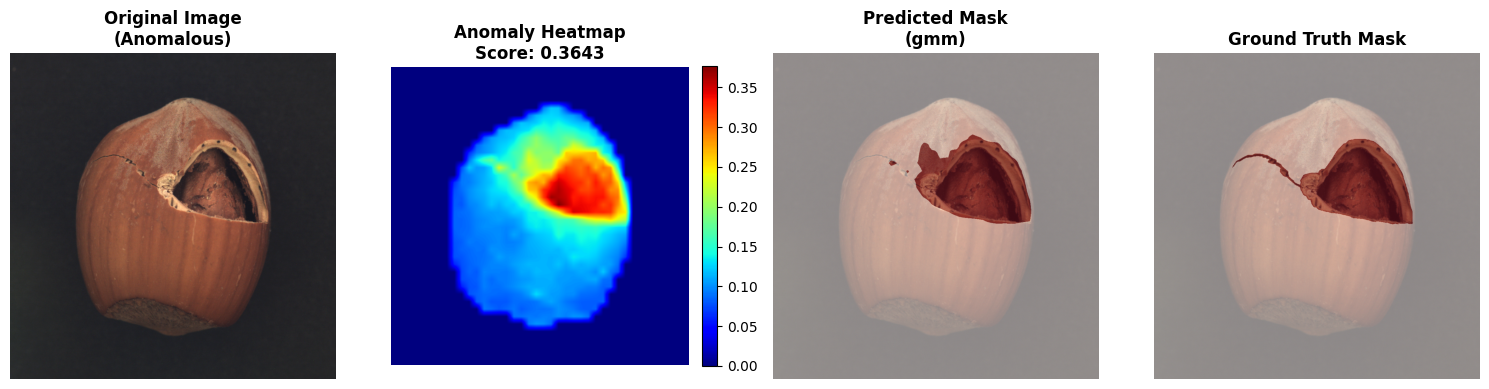

In [6]:
# Visualize a grid of results
from evaluation.visualization import plot_result_grid

ref_images, test_images, test_labels, test_masks = load_mvtec_data(
  dataset_path,
  'hazelnut',
)
plot_result_grid(
  results=test_result,
  test_images=test_images,
  test_labels=test_labels,
  test_masks=test_masks,
  sigma=0,
  num_display=6,  # number of examples to show
)

## 3. Run Complete Evaluation

In [7]:
# Run evaluation
results = run_evaluation(
    method_fn=run_few_shot,
    method_name='few_shot',
    model=model,
    dataset_path=dataset_path,
    objects=objects_to_eval,
    k_values=CONFIG['k_values'],
    method_kwargs={
        'use_rotation': CONFIG['use_rotation'], 
        'use_masking': CONFIG['use_masking'], 
        'masking_method': CONFIG['masking_method'], 
        'segmentation_method': CONFIG['segmentation_method'], 
        'k_neighbors': CONFIG['k_neighbors']
    }
)

results.description = f"Few-shot: rotation={CONFIG['use_rotation']}, masking={CONFIG['use_masking']}"
results.save(CONFIG['output_dir'] / 'experiment_results')
print('✓ Evaluation complete and saved')

Evaluation of anomaly detection with:  few_shot

Evaluating: hazelnut

Loaded 2 reference images for hazelnut
Loaded 110 test images (70 anomalous, 40 normal)
Running 1_shot evaluation on hazelnut...
Building memory bank from 1 images...
Rotation augmentation: True


Processing reference images:   0%|          | 0/1 [00:00<?, ?it/s]

Memory bank built! Index size: 12800, hnswlib HNSW index


Detecting anomalies (hazelnut):   0%|          | 0/110 [00:00<?, ?it/s]

  AUROC: 0.9811, AU-PRO: 0.9155, IoU: 0.4413
Running 2_shot evaluation on hazelnut...
Building memory bank from 2 images...
Rotation augmentation: True


Processing reference images:   0%|          | 0/2 [00:00<?, ?it/s]

Memory bank built! Index size: 25600, hnswlib HNSW index


Detecting anomalies (hazelnut):   0%|          | 0/110 [00:00<?, ?it/s]

  AUROC: 0.9796, AU-PRO: 0.9075, IoU: 0.4632
✓ Evaluation complete and saved


## 3b. Run Zero-Shot Evaluation

In [8]:
# Run zero-shot evaluation
# Zero-shot uses leave-one-out approach: for each test image, all other test images form the memory bank
zero_shot_results = run_evaluation(
    method_fn=run_zero_shot,
    method_name='zero_shot',
    model=model,
    dataset_path=dataset_path,
    objects=objects_to_eval,
    k_values=[1],  # k_value doesn't matter for zero-shot, just need one iteration
    method_kwargs={
        'use_masking': CONFIG['use_masking'],
        'masking_method': CONFIG['masking_method'], 
        'segmentation_method': CONFIG['segmentation_method'],
    }
)

zero_shot_results.description = f"Zero-shot: masking={CONFIG['use_masking']}"
zero_shot_results.save(CONFIG['output_dir'] / 'zero_shot_results')
print('✓ Zero-shot evaluation complete and saved')


Evaluation of anomaly detection with:  zero_shot

Evaluating: hazelnut

Loaded 1 reference images for hazelnut
Loaded 110 test images (70 anomalous, 40 normal)
Running zero_shot evaluation on hazelnut...


Detecting anomalies (hazelnut):   0%|          | 0/110 [00:00<?, ?it/s]

Building memory bank from 109 images...
Rotation augmentation: False


Processing reference images:   0%|          | 0/109 [00:00<?, ?it/s]

Memory bank built! Index size: 174400, hnswlib HNSW index
Building memory bank from 109 images...
Rotation augmentation: False


...

Memory bank built! Index size: 174400, hnswlib HNSW index
Building memory bank from 109 images...
Rotation augmentation: False


Processing reference images:   0%|          | 0/109 [00:00<?, ?it/s]

Memory bank built! Index size: 174400, hnswlib HNSW index
Building memory bank from 109 images...
Rotation augmentation: False


Processing reference images:   0%|          | 0/109 [00:00<?, ?it/s]

Memory bank built! Index size: 174400, hnswlib HNSW index
  AUROC: 0.9539, AU-PRO: 0.8732, IoU: 0.2116
✓ Zero-shot evaluation complete and saved


## 4. Analyze Results

In [9]:
# Summary
summary = results.summary_table()
print('Summary Statistics:')
print(summary.to_string(index=False))

best = summary.iloc[0]
print(f"\nBest: {best['Method']} - AUROC: {best['Mean AUROC']:.4f}")

Summary Statistics:
Method  Mean AUROC  Std AUROC  Mean AU-PRO  Std AU-PRO  Mean Pixel AUROC  Mean Pixel F1  Mean IoU  Num Objects
1_shot    0.981071        0.0     0.915501         0.0          0.992783       0.813020  0.441313            1
2_shot    0.979643        0.0     0.907458         0.0          0.993027       0.814642  0.463203            1

Best: 1_shot - AUROC: 0.9811


In [10]:
# Per-object
per_obj = results.per_object_table()
pivot = per_obj.pivot_table(index='Object', columns='Method', values='AUROC')
print('AUROC by Object:')
print(pivot.to_string())

AUROC by Object:
Method      1_shot    2_shot
Object                      
hazelnut  0.981071  0.979643


## 5. Visualizations

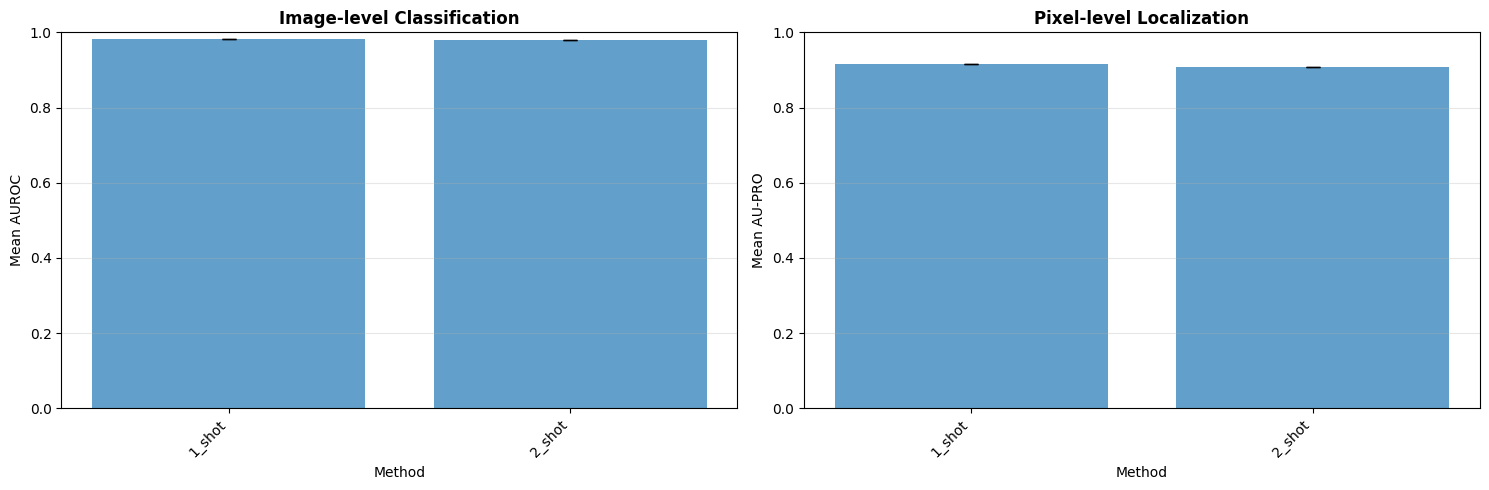

In [11]:
plot_method_comparison(results, metrics=['auroc', 'aupro'])

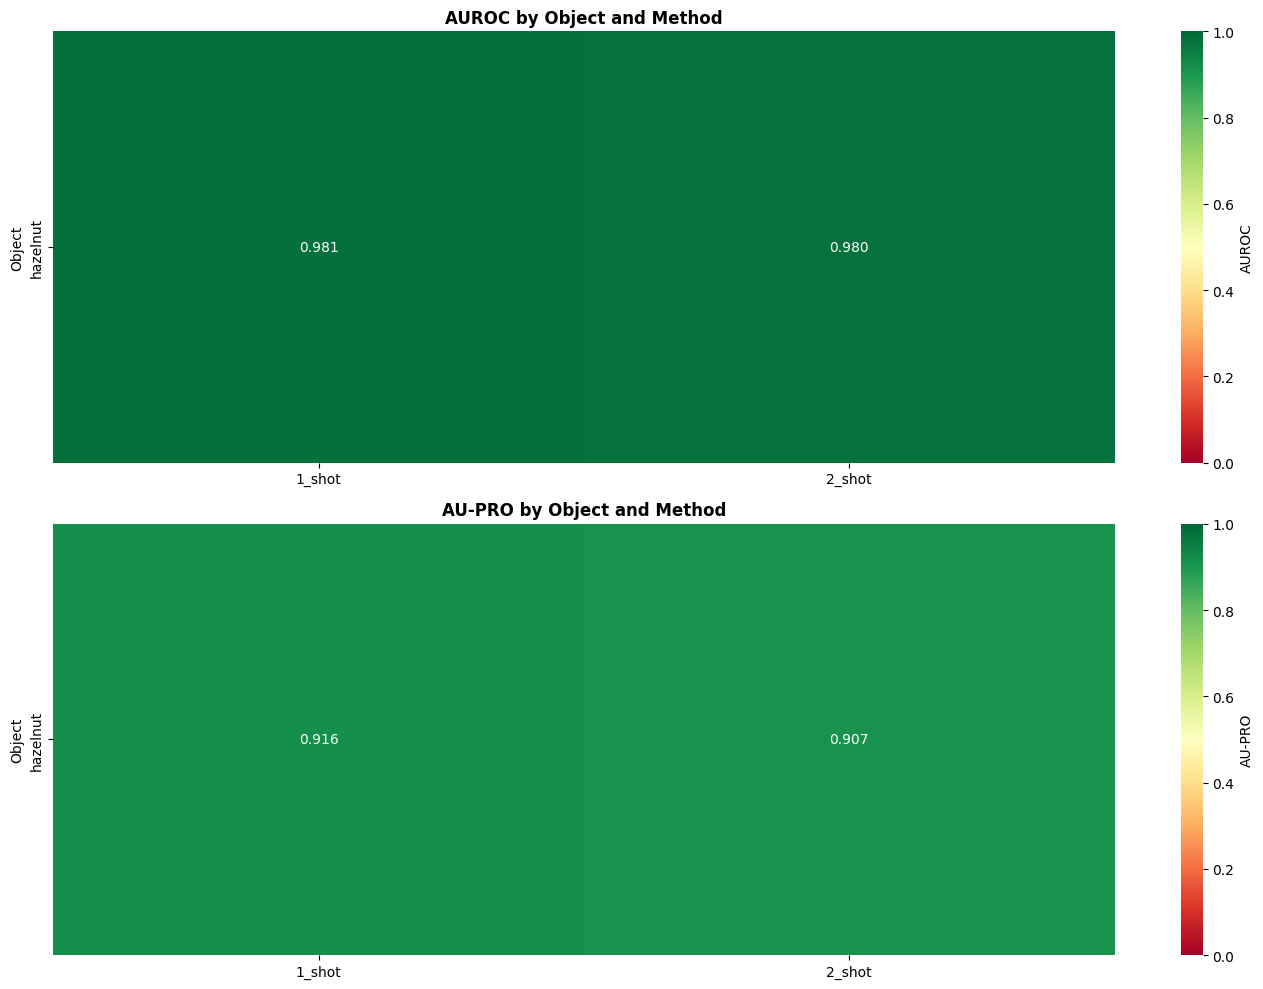

In [12]:
plot_object_heatmap(results, metrics=['AUROC', 'AU-PRO'])

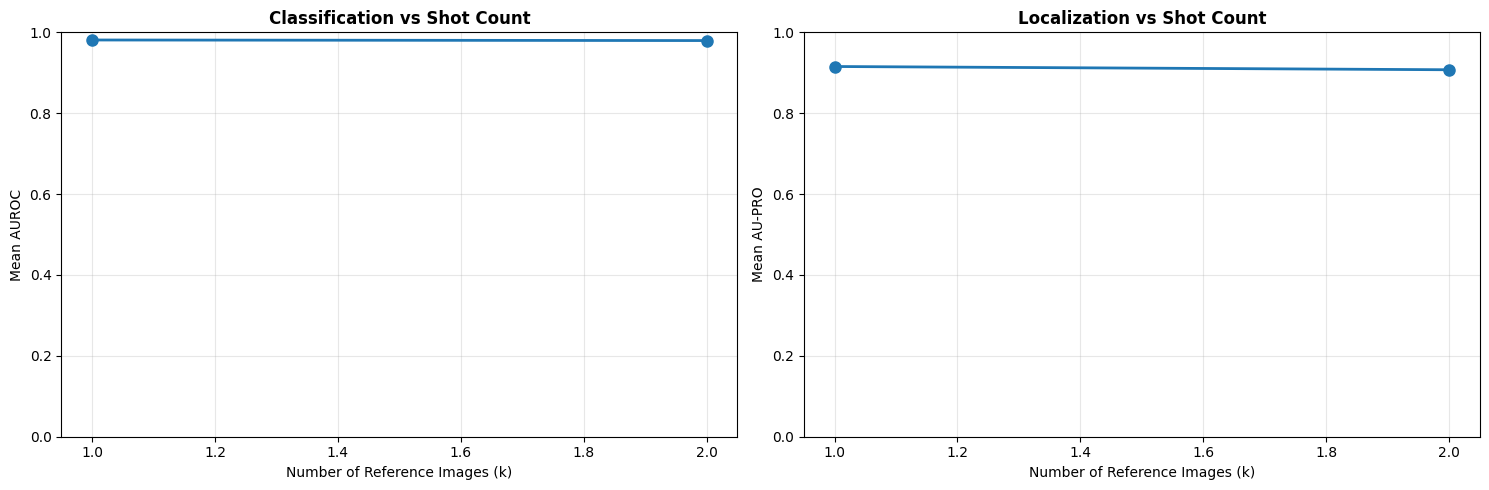


Improvement from 1-shot to 2-shot:
  AUROC: 0.9811 → 0.9796 (+-0.1%)
  AUPRO: 0.9155 → 0.9075 (+-0.9%)


In [13]:
if len(CONFIG['k_values']) > 1:
    plot_shot_count_analysis(results, k_values=CONFIG['k_values'], metrics=['auroc', 'aupro'])

## 6. Compare Methods

In [14]:
if len(results.list_methods()) >= 2:
    comp = results.compare_methods('1_shot', '8_shot', metric='auroc')
    print(comp.to_string(index=False))

Empty DataFrame
Columns: []
Index: []


## 7. Export Results

In [15]:
export_all(results, CONFIG['output_dir'] / 'exports')
print('✓ Results exported')

Exporting results in all formats...
Results exported to evaluation_results_clean\exports\results.json
Summary statistics saved to evaluation_results_clean\exports\summary.csv
Per-object results saved to evaluation_results_clean\exports\per_object.csv

All exports completed! Results saved to: evaluation_results_clean\exports
✓ Results exported


## 8. Compare Few-Shot vs Zero-Shot

In [16]:
# Merge few-shot and zero-shot results for comparison
combined_results = results.merge(zero_shot_results)
print(f"Combined methods: {combined_results.list_methods()}")
print(f"Objects evaluated: {len(combined_results.list_objects())}")

Combined methods: ['1_shot', '2_shot', 'zero_shot']
Objects evaluated: 1


In [17]:
# Summary table for all methods (few-shot variants + zero-shot)
combined_summary = combined_results.summary_table()
print('Combined Summary Statistics (Few-Shot + Zero-Shot):')
print(combined_summary.to_string(index=False))

Combined Summary Statistics (Few-Shot + Zero-Shot):
   Method  Mean AUROC  Std AUROC  Mean AU-PRO  Std AU-PRO  Mean Pixel AUROC  Mean Pixel F1  Mean IoU  Num Objects
   1_shot    0.981071        0.0     0.915501         0.0          0.992783       0.813020  0.441313            1
   2_shot    0.979643        0.0     0.907458         0.0          0.993027       0.814642  0.463203            1
zero_shot    0.953929        0.0     0.873191         0.0          0.992051       0.787649  0.211646            1


In [18]:
# Statistical comparison: Zero-Shot vs 8-Shot (best few-shot)
print("Statistical Comparison: Zero-Shot vs 8-Shot")
print("=" * 60)
comp_zs_8s = combined_results.compare_methods('zero_shot', '8_shot', metric='auroc')
print(comp_zs_8s.to_string(index=False))

Statistical Comparison: Zero-Shot vs 8-Shot
Empty DataFrame
Columns: []
Index: []


In [19]:
# Per-object comparison table including zero-shot
combined_per_obj = combined_results.per_object_table()
combined_pivot = combined_per_obj.pivot_table(index='Object', columns='Method', values='AUROC')
print('AUROC by Object (All Methods):')
print(combined_pivot.to_string())

AUROC by Object (All Methods):
Method      1_shot    2_shot  zero_shot
Object                                 
hazelnut  0.981071  0.979643   0.953929


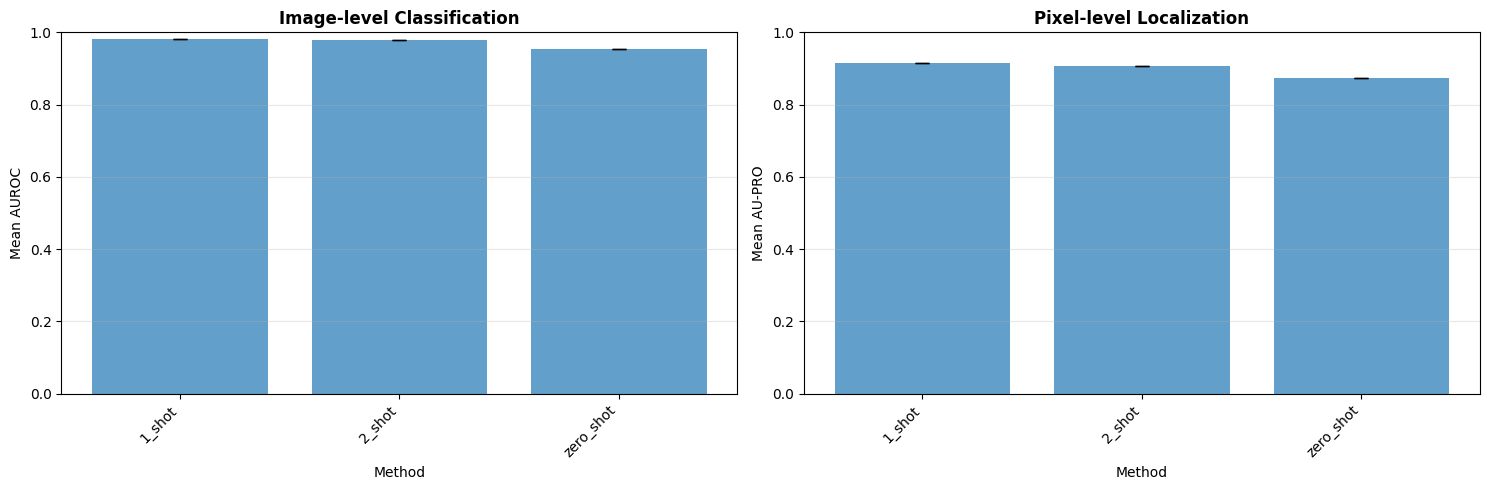

In [20]:
# Visualize method comparison including zero-shot
plot_method_comparison(combined_results, metrics=['auroc', 'aupro'])

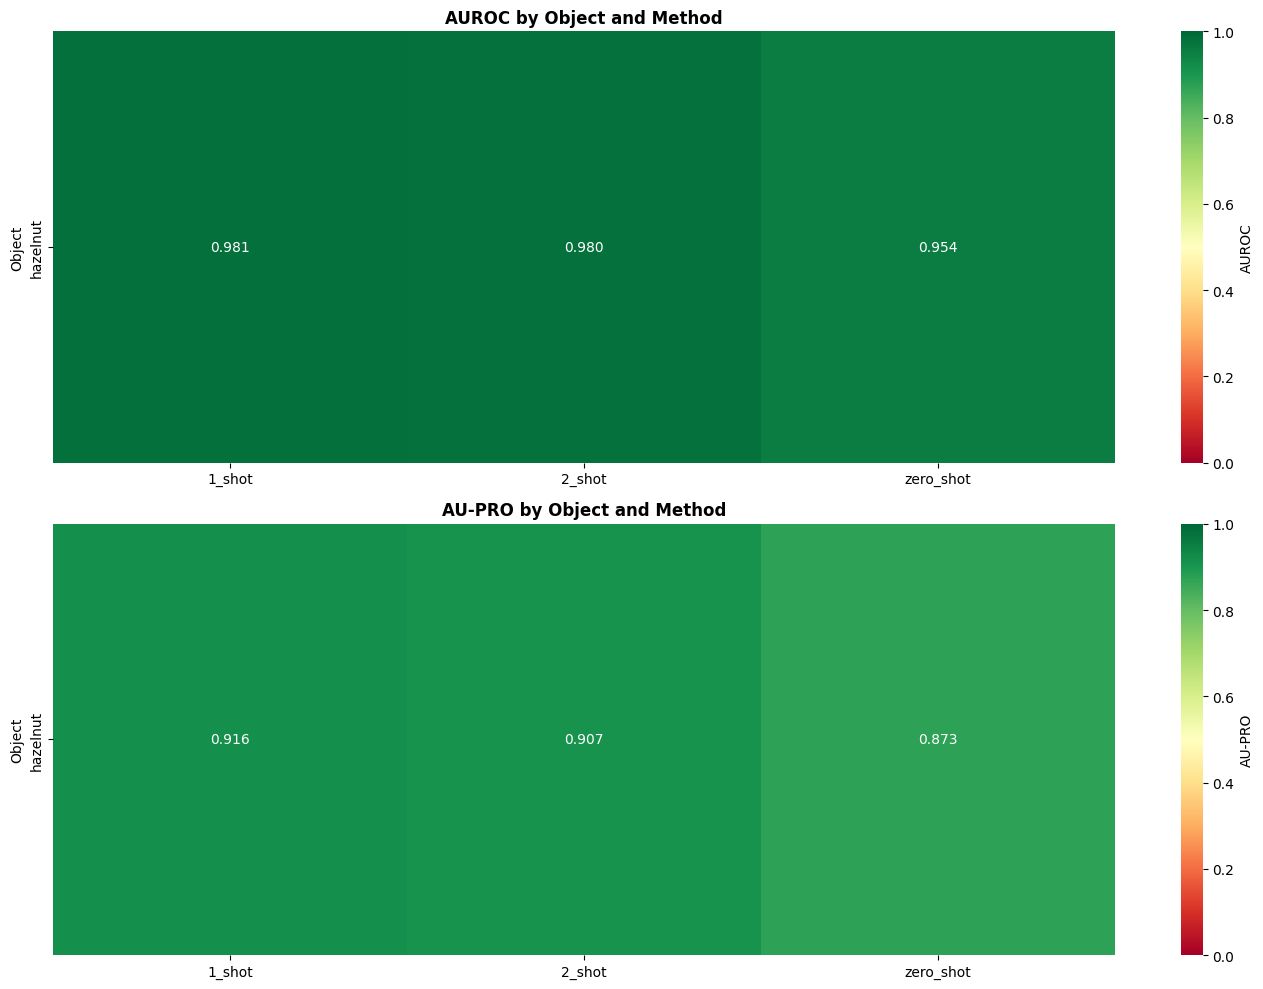

In [21]:
# Heatmap comparing all methods including zero-shot
plot_object_heatmap(combined_results, metrics=['AUROC', 'AU-PRO'])

In [22]:
# Export combined results
combined_results.save(CONFIG['output_dir'] / 'combined_results')
export_all(combined_results, CONFIG['output_dir'] / 'combined_exports')
print('✓ Combined results exported')

Exporting results in all formats...
Results exported to evaluation_results_clean\combined_exports\results.json
Summary statistics saved to evaluation_results_clean\combined_exports\summary.csv
Per-object results saved to evaluation_results_clean\combined_exports\per_object.csv

All exports completed! Results saved to: evaluation_results_clean\combined_exports
✓ Combined results exported


## 9. Add Your Own Method

See `evaluation/README.md` for complete instructions on adding custom methods.

**Quick template:**

```python
def run_my_method(model, reference_images, test_images, test_labels, test_masks, object_name, **kwargs):
    from evaluation import MethodResults, compute_auroc, compute_pro, compute_iou
    
    # Your detection logic
    scores = ...
    maps = ...
    
    # Compute metrics
    auroc = compute_auroc(test_labels, scores)
    # ... other metrics ...
    
    return MethodResults(
        method_name='my_method',
        object_name=object_name,
        scores=scores,
        maps=maps,
        metrics={'auroc': auroc, ...},
        config=kwargs
    )

# Use it
my_results = run_evaluation(method_fn=run_my_method, ...)
```